# Step 2 — Build the Case-Step Feature Table

This notebook completes **Step 2 only**.

Goal: create one row per event-in-case, with time, sequence, and branch features for RL.

## What we do in this step (simple view)

1. Load all municipality logs again.
2. Load `graph_priors.json` from Step 1.
3. Build ordered traces for each `Application` case.
4. Create one feature row per event step.
5. Save the table for later RL steps.

In [2]:
%pip install pandas pyarrow openpyxl matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import json
from pathlib import Path
from collections import defaultdict

import pandas as pd

DATASET_DIR = Path('./dataset')
OUTPUT_DIR = Path('./output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PRIORS_PATH = OUTPUT_DIR / 'graph_priors.json'
MUNICIPALITIES = [1, 2, 3, 4, 5]

print('Dataset dir:', DATASET_DIR.resolve())
print('Output dir :', OUTPUT_DIR.resolve())
print('Priors file:', PRIORS_PATH.resolve())

Dataset dir: /mnt/HDD/Code/Git/bureaucratic-workflow-analyzer/dataset
Output dir : /mnt/HDD/Code/Git/bureaucratic-workflow-analyzer/output
Priors file: /mnt/HDD/Code/Git/bureaucratic-workflow-analyzer/output/graph_priors.json


In [4]:
def load_ocel(path: Path) -> dict:
    with open(path, 'r') as f:
        return json.load(f)

if not PRIORS_PATH.exists():
    print('Error: previous notebook should be run first (Step 1 missing graph_priors.json).')
    raise SystemExit(1)

with open(PRIORS_PATH, 'r') as f:
    priors = json.load(f)

logs = {}
for m in MUNICIPALITIES:
    path = DATASET_DIR / f'BPIC15_Municipality{m}.jsonocel'
    logs[m] = load_ocel(path)
    event_count = len(logs[m]['ocel:events'])
    print(f'M{m}: {event_count:,} events loaded')

print('Loaded priors keys:', list(priors.keys()))

M1: 52,217 events loaded
M2: 44,354 events loaded
M3: 59,681 events loaded
M4: 47,293 events loaded
M5: 59,083 events loaded
Loaded priors keys: ['config', 'backbone_edges', 'rare_edges_by_municipality', 'top_transitions_by_municipality', 'activity_rank_by_municipality']


## Helper logic

We need three helpers:
- ordered events per `Application` case
- branch signal mapping from rare/backbone edges
- row builder for each event step

In [5]:
# Builds case event sequences for each municipality
# Groups events by case (object of type 'Application') and sort them by timestamp
# It outputs a dict of case_id -> list of events, where each event is a dict with keys: event_id, timestamp, activity
def build_case_event_sequences(log: dict, object_type: str = 'Application'):
    events = log['ocel:events']
    objects = log['ocel:objects']

    case_ids = {oid for oid, obj in objects.items() if obj['ocel:type'] == object_type}

    by_case = defaultdict(list)
    for event_id, event in events.items():
        ts = pd.to_datetime(event['ocel:timestamp'], utc=True, errors='coerce')
        act = event['ocel:activity']
        related_cases = [oid for oid in event.get('ocel:omap', []) if oid in case_ids]
        for case_id in related_cases:
            by_case[case_id].append({
                'event_id': event_id,
                'timestamp': ts,
                'activity': act
            })

    for case_id in by_case:
        by_case[case_id].sort(key=lambda x: x['timestamp'])

    return by_case

# Builds a lookup for activity ranks by municipality
# Ranks activities by their frequency in the municipality graph priors
# It outputs a dict of municipality -> dict of activity -> rank (float)
def build_stage_rank_lookup(priors_dict: dict):
    stage_lookup = {}
    rank_map = priors_dict.get('activity_rank_by_municipality', {})
    for m_str, activity_map in rank_map.items():
        m = int(m_str)
        stage_lookup[m] = {a: float(r) for a, r in activity_map.items()}
    return stage_lookup

# Builds municipality-specific rare-edge sets and one backbone set
# Rare edges MUST stay municipality-specific (no cross-municipality union)
def build_branch_edge_sets(priors_dict: dict):
    rare_by_m_raw = priors_dict.get('rare_edges_by_municipality', {})

    rare_by_municipality = {}
    for m_str, edges in rare_by_m_raw.items():
        m = int(m_str)
        rare_by_municipality[m] = {
            (edge['src'], edge['tgt'])
            for edge in edges
        }

    backbone = set()
    for edge in priors_dict.get('backbone_edges', []):
        backbone.add((edge['src'], edge['tgt']))

    return rare_by_municipality, backbone

In [6]:
# Robust branch inference helpers
# Strategy:
# 1) anchor branch evidence from text patterns
# 2) learn transition-edge -> branch label map on decision edges
# 3) assign per-step label with confidence (edge map first, lookahead fallback)
#
# The term lists below were expanded using branch_term_mining.ipynb.
# Only relatively specific phrases were added to avoid over-labeling generic steps.

REFUSAL_TERMS = [
    'refusal',
    'no permit needed',
    'objection lodged',
    'grounds for refusal',
    'grounds refusal',
    'wabo applies',
    'article 34',
    'refusal reassessment',
    'plan refusal',
]

SUSPENSION_TERMS = [
    'suspension',
    'suspend term',
    'extend procedure',
    'permanent suspension',
    'irrevocable suspension',
    'suspension date',
    'suspension copy',
    'suspension objection',
]

COMPLETENESS_TERMS = [
    'completeness',
    'subcases content',
    'subcases completed',
    'resume completeness',
    'request complete',
    'send procedure confirmation',
]

COMPLETION_TERMS = [
    'close case',
    'phase archived',
    'terminate on request',
    'irrevocable',
    'decision permitting sent',
    'decision environmental permit',
    'publication decision environmental permit',
    'record date of decision environmental permit',
    'set phase decision revoked',
    'decision permanent suspension',
]

NON_COMPLETION_TERMS = [
    'objection lodged',
    'retrieve missing data',
    'acknowledgement',
    'register deadline',
    'date decision for inspection',
    'create publication document',
    'generate publication document',
    'send confirmation receipt',
]

BRANCH_TERMS = {
    'refusal': REFUSAL_TERMS,
    'suspension': SUSPENSION_TERMS,
    'completeness': COMPLETENESS_TERMS,
}

BRANCH_LABELS = ['refusal', 'suspension', 'completeness']


def _normalize_text(text: str) -> str:
    return (text or '').strip().lower()


def labels_from_text(text: str):
    normalized = _normalize_text(text)
    return {
        label
        for label, terms in BRANCH_TERMS.items()
        if any(term in normalized for term in terms)
    }


def infer_branch_flags(activity: str, transition_edge, is_rare_edge: bool):
    # Backward-compatible boolean flags from current + next activity text
    _ = is_rare_edge
    text = _normalize_text(activity)
    tgt_text = _normalize_text(transition_edge[1]) if transition_edge else ''
    combined = f'{text} {tgt_text}'

    labels = labels_from_text(combined)
    is_refusal_path = 'refusal' in labels
    is_suspension_path = 'suspension' in labels
    is_completeness_path = 'completeness' in labels

    return is_refusal_path, is_suspension_path, is_completeness_path


def build_edge_branch_model(case_sequences, lookahead: int = 3, min_support: int = 25, purity_threshold: float = 0.7):
    edge_label_counts = defaultdict(lambda: defaultdict(int))
    source_nexts = defaultdict(set)

    for events in case_sequences.values():
        n = len(events)
        for i in range(n - 1):
            src = events[i]['activity']
            tgt = events[i + 1]['activity']
            edge = (src, tgt)
            source_nexts[src].add(tgt)

            horizon = events[i:min(i + lookahead + 1, n)]
            labels = set()
            for ev in horizon:
                labels |= labels_from_text(ev['activity'])

            for label in labels:
                edge_label_counts[edge][label] += 1

    edge_branch_model = {}
    for edge, label_counts in edge_label_counts.items():
        src = edge[0]
        if len(source_nexts[src]) < 2:
            continue  # decision-point edges only

        total = sum(label_counts.values())
        if total < min_support:
            continue

        best_label = max(label_counts, key=label_counts.get)
        purity = label_counts[best_label] / total
        if purity >= purity_threshold:
            edge_branch_model[edge] = {
                'label': best_label,
                'confidence': float(purity),
                'support': int(total)
            }

    return edge_branch_model


def infer_branch_label_for_step(events, step_index: int, edge_branch_model: dict, lookahead: int = 3):
    curr = events[step_index]['activity']
    next_activity = events[step_index + 1]['activity'] if step_index < len(events) - 1 else None
    edge = (curr, next_activity) if next_activity is not None else None

    if edge is not None and edge in edge_branch_model:
        model_entry = edge_branch_model[edge]
        return model_entry['label'], float(model_entry['confidence']), 'edge_model'

    horizon = events[step_index:min(step_index + lookahead + 1, len(events))]
    votes = defaultdict(float)

    for dist, ev in enumerate(horizon):
        weight = 1.0 / (1.0 + dist)
        labels = labels_from_text(ev['activity'])
        for label in labels:
            votes[label] += weight

    if not votes:
        return 'unknown', 0.0, 'none'

    best_label = max(votes, key=votes.get)
    total_votes = sum(votes.values())
    confidence = float(votes[best_label] / total_votes) if total_votes > 0 else 0.0

    # avoid over-confident ambiguous assignments
    if confidence < 0.55:
        return 'unknown', confidence, 'lookahead_ambiguous'

    return best_label, confidence, 'lookahead'


def case_completed_heuristic(last_activity: str) -> bool:
    """Infer whether a real case appears completed from its final activity text.

    Important: this is used only to label historical real cases for calibration.
    If too strict, Step 6 underestimates completion targets; if too loose, it can
    encourage earlier simulated termination. We therefore use strong terminal
    cues, but block a few common 'still in progress' endings.
    """
    text = _normalize_text(last_activity)

    if any(term in text for term in NON_COMPLETION_TERMS):
        return False

    if any(term in text for term in COMPLETION_TERMS):
        return True

    return False

## Build one row per case step

Each row represents one event position inside a case trace, with context from previous and next events.

In [7]:
stage_rank_lookup = build_stage_rank_lookup(priors)
rare_edges_by_municipality, backbone_edges = build_branch_edge_sets(priors)

# Pre-build sequences once per municipality for reuse
case_sequences_by_m = {m: build_case_event_sequences(logs[m]) for m in MUNICIPALITIES}

# Learn edge->branch models per municipality (decision-point transitions only)
edge_branch_models = {}
for m in MUNICIPALITIES:
    edge_branch_models[m] = build_edge_branch_model(
        case_sequences_by_m[m],
        lookahead=3,
        min_support=25,
        purity_threshold=0.70
    )
    print(f'M{m}: learned {len(edge_branch_models[m])} branch-labeled transition edges')

rows = []

for m in MUNICIPALITIES:
    case_sequences = case_sequences_by_m[m]
    ranks = stage_rank_lookup.get(m, {})
    rare_edges_for_m = rare_edges_by_municipality.get(m, set())
    edge_branch_model = edge_branch_models[m]

    for case_id, events in case_sequences.items():
        if not events:
            continue

        case_start = events[0]['timestamp']
        trace_length = len(events)
        activity_seen_count = defaultdict(int)

        last_activity = events[-1]['activity']
        case_will_complete = case_completed_heuristic(last_activity)

        for i, ev in enumerate(events):
            curr_activity = ev['activity']
            curr_ts = ev['timestamp']

            prev_activity = events[i - 1]['activity'] if i > 0 else None
            next_activity = events[i + 1]['activity'] if i < (trace_length - 1) else None

            prev_ts = events[i - 1]['timestamp'] if i > 0 else None
            delta_case_hours = (curr_ts - case_start).total_seconds() / 3600.0
            delta_prev_hours = ((curr_ts - prev_ts).total_seconds() / 3600.0) if prev_ts is not None else 0.0

            transition_edge = (curr_activity, next_activity) if next_activity is not None else None
            is_rare_edge = transition_edge in rare_edges_for_m if transition_edge else False
            is_backbone_edge = transition_edge in backbone_edges if transition_edge else False

            seen_before = activity_seen_count[curr_activity] > 0
            rework_count_activity = activity_seen_count[curr_activity]
            activity_seen_count[curr_activity] += 1

            (
                branch_label,
                branch_confidence,
                branch_source,
            ) = infer_branch_label_for_step(
                events=events,
                step_index=i,
                edge_branch_model=edge_branch_model,
                lookahead=3
            )

            is_refusal_path = bool(branch_label == 'refusal')
            is_suspension_path = bool(branch_label == 'suspension')
            is_completeness_path = bool(branch_label == 'completeness')

            is_terminal_event = bool(i == trace_length - 1)

            rows.append({
                'municipality': m,
                'case_id': case_id,
                'event_id': ev['event_id'],
                'timestamp': curr_ts,
                'activity': curr_activity,
                'prev_activity': prev_activity,
                'next_activity': next_activity,
                'step_index': i,
                'trace_length': trace_length,
                'stage_rank': ranks.get(curr_activity, 0.5),
                'time_since_case_start_hours': max(delta_case_hours, 0.0),
                'time_since_prev_hours': max(delta_prev_hours, 0.0),
                'rework_count_activity': rework_count_activity,
                'seen_activity_before': bool(seen_before),
                'is_rare_transition_to_next': bool(is_rare_edge),
                'is_backbone_transition_to_next': bool(is_backbone_edge),
                'branch_label': branch_label,
                'branch_confidence': float(branch_confidence),
                'branch_source': branch_source,
                'is_refusal_path': is_refusal_path,
                'is_suspension_path': is_suspension_path,
                'is_completeness_path': is_completeness_path,
                'is_unknown_branch': bool(branch_label == 'unknown'),
                'is_terminal_event': is_terminal_event,
                'case_will_complete': bool(case_will_complete),
                'case_completed': bool(is_terminal_event and case_will_complete)
            })

features_df = pd.DataFrame(rows).sort_values(['municipality', 'case_id', 'timestamp', 'event_id']).reset_index(drop=True)

print('Rows:', len(features_df))
print('Columns:', len(features_df.columns))
print('Branch label distribution:')
print(features_df['branch_label'].value_counts(dropna=False).to_string())
features_df.head(5)

M1: learned 129 branch-labeled transition edges
M2: learned 124 branch-labeled transition edges
M3: learned 121 branch-labeled transition edges
M4: learned 133 branch-labeled transition edges
M5: learned 167 branch-labeled transition edges
Rows: 262628
Columns: 26
Branch label distribution:
branch_label
unknown         111513
completeness     91500
refusal          36918
suspension       22697


,municipality,case_id,event_id,timestamp,activity,prev_activity,next_activity,step_index,trace_length,stage_rank,...,branch_label,branch_confidence,branch_source,is_refusal_path,is_suspension_path,is_completeness_path,is_unknown_branch,is_terminal_event,case_will_complete,case_completed
0,1,44688,268496,2011-07-08 00:00:00+00:00,register submission date request,NaN,phase application received,0,43,0.009373,...,unknown,0.0,none,False,False,False,True,False,False,False
1,1,44688,268497,2011-07-18 08:59:43+00:00,phase application received,register submission date request,terminate on request,1,43,0.144496,...,refusal,1.0,lookahead,True,False,False,False,False,False,False
2,1,44688,268498,2011-07-18 08:59:50+00:00,terminate on request,phase application received,applicant is stakeholder,2,43,0.358921,...,refusal,1.0,lookahead,True,False,False,False,False,False,False
3,1,44688,268499,2011-07-18 08:59:55+00:00,applicant is stakeholder,terminate on request,no permit needed or only notification needed,3,43,0.340811,...,refusal,1.0,lookahead,True,False,False,False,False,False,False
4,1,44688,268500,2011-07-18 09:00:02+00:00,no permit needed or only notification needed,applicant is stakeholder,send confirmation receipt,4,43,0.261181,...,refusal,1.0,lookahead,True,False,False,False,False,False,False


## Important feature rows + pie charts

Quick inspection block after building `features_df`:
- globally (first rows),
- per municipality (first rows),
- pie charts for branch-label distribution globally and by municipality.

=== Global important feature rows (first 10) ===


,municipality,case_id,event_id,timestamp,activity,step_index,trace_length,stage_rank,time_since_case_start_hours,time_since_prev_hours,rework_count_activity,seen_activity_before,is_rare_transition_to_next,is_backbone_transition_to_next,branch_label,branch_confidence,is_terminal_event,case_will_complete,case_completed
0,1,44688,268496,2011-07-08 00:00:00+00:00,register submission date request,0,43,0.009373,0.000000,0.000000,0,False,False,True,unknown,0.000000,False,False,False
1,1,44688,268497,2011-07-18 08:59:43+00:00,phase application received,1,43,0.144496,248.995278,248.995278,0,False,False,False,refusal,1.000000,False,False,False
2,1,44688,268498,2011-07-18 08:59:50+00:00,terminate on request,2,43,0.358921,248.997222,0.001944,0,False,False,False,refusal,1.000000,False,False,False
3,1,44688,268499,2011-07-18 08:59:55+00:00,applicant is stakeholder,3,43,0.340811,248.998611,0.001389,0,False,False,False,refusal,1.000000,False,False,False
4,1,44688,268500,2011-07-18 09:00:02+00:00,no permit needed or only notification needed,4,43,0.261181,249.000556,0.001944,0,False,False,False,refusal,1.000000,False,False,False
5,1,44688,268501,2011-07-18 09:00:07+00:00,send confirmation receipt,5,43,0.145895,249.001944,0.001389,0,False,False,True,completeness,0.838235,False,False,False
6,1,44688,268502,2011-07-18 11:02:51+00:00,enter senddate acknowledgement,6,43,0.191487,251.047500,2.045556,0,False,False,True,unknown,0.000000,False,False,False
7,1,44688,268503,2011-07-18 11:02:51+00:00,send confirmation receipt,7,43,0.145895,251.047500,0.000000,1,True,False,True,completeness,0.957983,False,False,False
8,1,44688,268504,2011-07-18 11:02:55+00:00,forward to the competent authority,8,43,0.157219,251.048611,0.001111,0,False,False,True,completeness,0.908925,False,False,False
9,1,44688,268505,2011-07-18 11:03:05+00:00,regular procedure without MER,9,43,0.179956,251.051389,0.002778,0,False,False,True,completeness,0.795322,False,False,False



=== Important feature rows by municipality (first 10 each) ===

Municipality M1


,municipality,case_id,event_id,timestamp,activity,step_index,trace_length,stage_rank,time_since_case_start_hours,time_since_prev_hours,rework_count_activity,seen_activity_before,is_rare_transition_to_next,is_backbone_transition_to_next,branch_label,branch_confidence,is_terminal_event,case_will_complete,case_completed
0,1,44688,268496,2011-07-08 00:00:00+00:00,register submission date request,0,43,0.009373,0.000000,0.000000,0,False,False,True,unknown,0.000000,False,False,False
1,1,44688,268497,2011-07-18 08:59:43+00:00,phase application received,1,43,0.144496,248.995278,248.995278,0,False,False,False,refusal,1.000000,False,False,False
2,1,44688,268498,2011-07-18 08:59:50+00:00,terminate on request,2,43,0.358921,248.997222,0.001944,0,False,False,False,refusal,1.000000,False,False,False
3,1,44688,268499,2011-07-18 08:59:55+00:00,applicant is stakeholder,3,43,0.340811,248.998611,0.001389,0,False,False,False,refusal,1.000000,False,False,False
4,1,44688,268500,2011-07-18 09:00:02+00:00,no permit needed or only notification needed,4,43,0.261181,249.000556,0.001944,0,False,False,False,refusal,1.000000,False,False,False
5,1,44688,268501,2011-07-18 09:00:07+00:00,send confirmation receipt,5,43,0.145895,249.001944,0.001389,0,False,False,True,completeness,0.838235,False,False,False
6,1,44688,268502,2011-07-18 11:02:51+00:00,enter senddate acknowledgement,6,43,0.191487,251.047500,2.045556,0,False,False,True,unknown,0.000000,False,False,False
7,1,44688,268503,2011-07-18 11:02:51+00:00,send confirmation receipt,7,43,0.145895,251.047500,0.000000,1,True,False,True,completeness,0.957983,False,False,False
8,1,44688,268504,2011-07-18 11:02:55+00:00,forward to the competent authority,8,43,0.157219,251.048611,0.001111,0,False,False,True,completeness,0.908925,False,False,False
9,1,44688,268505,2011-07-18 11:03:05+00:00,regular procedure without MER,9,43,0.179956,251.051389,0.002778,0,False,False,True,completeness,0.795322,False,False,False



Municipality M2


...

,municipality,case_id,event_id,timestamp,activity,step_index,trace_length,stage_rank,time_since_case_start_hours,time_since_prev_hours,rework_count_activity,seen_activity_before,is_rare_transition_to_next,is_backbone_transition_to_next,branch_label,branch_confidence,is_terminal_event,case_will_complete,case_completed
96571,3,45676,199998,2012-04-20 00:00:00+00:00,register submission date request,0,26,0.002331,0.000000,0.000000,0,False,False,True,unknown,0.000000,False,True,False
96572,3,45676,199999,2012-04-23 12:35:43+00:00,OLO messaging active,1,26,0.037566,84.595278,84.595278,0,False,True,False,unknown,0.000000,False,True,False
96573,3,45676,200000,2012-04-23 12:35:43+00:00,applicant is stakeholder,2,26,0.162320,84.595278,0.000000,0,False,True,False,unknown,0.000000,False,True,False
96574,3,45676,200001,2012-04-23 12:35:43+00:00,phase application received,3,26,0.112383,84.595278,0.000000,0,False,False,True,refusal,0.847458,False,True,False
96575,3,45676,200002,2012-04-23 12:35:46+00:00,send confirmation receipt,4,26,0.152393,84.596111,0.000833,0,False,False,False,unknown,0.000000,False,True,False
96576,3,45676,100002,2012-04-23 13:38:32+00:00,send confirmation receipt,5,26,0.152393,85.642222,1.046111,1,True,False,True,refusal,0.757143,False,True,False
96577,3,45676,100003,2012-04-23 13:38:32+00:00,enter senddate acknowledgement,6,26,0.157336,85.642222,0.000000,0,False,False,True,unknown,0.000000,False,True,False
96578,3,45676,100004,2012-05-02 10:09:46+00:00,forward to the competent authority,7,26,0.207770,298.162778,212.520556,0,False,False,False,completeness,0.886957,False,True,False
96579,3,45676,100005,2012-05-02 10:09:46+00:00,inform BAG administrator,8,26,0.263694,298.162778,0.000000,0,False,False,False,completeness,0.887574,False,True,False
96580,3,45676,100006,2012-05-02 10:09:49+00:00,regular procedure without MER,9,26,0.212481,298.163611,0.000833,0,False,False,True,completeness,0.713666,False,True,False



Municipality M4


,municipality,case_id,event_id,timestamp,activity,step_index,trace_length,stage_rank,time_since_case_start_hours,time_since_prev_hours,rework_count_activity,seen_activity_before,is_rare_transition_to_next,is_backbone_transition_to_next,branch_label,branch_confidence,is_terminal_event,case_will_complete,case_completed
156252,4,44633,149974,2011-02-24 00:00:00+00:00,suspension ground applicable,0,49,0.597510,0.000000,0.000000,0,False,False,False,suspension,1.000000,False,False,False
156253,4,44633,149975,2011-06-17 00:00:00+00:00,enter senddate acknowledgement,1,49,0.066311,2712.000000,2712.000000,0,False,False,False,unknown,0.000000,False,False,False
156254,4,44633,149976,2011-06-17 00:00:00+00:00,enter senddate procedure confirmation,2,49,0.239012,2712.000000,0.000000,0,False,False,False,unknown,0.000000,False,False,False
156255,4,44633,149977,2011-06-17 11:35:03+00:00,register submission date request,3,49,0.019046,2723.584167,11.584167,0,False,False,True,unknown,0.000000,False,False,False
156256,4,44633,149978,2011-06-17 11:39:49+00:00,phase application received,4,49,0.188135,2723.663611,0.079444,0,False,False,True,unknown,0.000000,False,False,False
156257,4,44633,149979,2011-06-17 11:39:53+00:00,reception through OLO,5,49,0.112176,2723.664722,0.001111,0,False,False,True,unknown,0.000000,False,False,False
156258,4,44633,149980,2011-06-17 11:39:55+00:00,send confirmation receipt,6,49,0.077628,2723.665278,0.000556,0,False,False,True,completeness,0.960526,False,False,False
156259,4,44633,149981,2011-06-17 11:40:02+00:00,forward to the competent authority,7,49,0.126338,2723.667222,0.001944,0,False,False,True,completeness,0.967391,False,False,False
156260,4,44633,149982,2011-06-17 11:40:04+00:00,regular procedure without MER,8,49,0.160998,2723.667778,0.000556,0,False,False,True,completeness,0.813953,False,False,False
156261,4,44633,149983,2011-06-17 11:40:09+00:00,send procedure confirmation,9,49,0.273107,2723.669167,0.001389,0,False,True,False,completeness,0.968992,False,False,False



Municipality M5


,municipality,case_id,event_id,timestamp,activity,step_index,trace_length,stage_rank,time_since_case_start_hours,time_since_prev_hours,rework_count_activity,seen_activity_before,is_rare_transition_to_next,is_backbone_transition_to_next,branch_label,branch_confidence,is_terminal_event,case_will_complete,case_completed
203545,5,43790,99987,2010-11-30 00:00:00+00:00,register submission date request,0,54,0.004123,0.000000,0.000000,0,False,False,False,unknown,0.000000,False,True,False
203546,5,43790,99988,2010-12-02 00:00:00+00:00,registrer date of publishing received request,1,54,0.221572,48.000000,48.000000,0,False,False,False,unknown,0.000000,False,True,False
203547,5,43790,99989,2010-12-20 00:00:00+00:00,enter senddate retrieve missing data,2,54,0.320736,480.000000,432.000000,0,False,False,False,unknown,0.000000,False,True,False
203548,5,43790,99990,2010-12-20 00:00:00+00:00,enter senddate procedure confirmation,3,54,0.192486,480.000000,0.000000,0,False,False,False,unknown,0.000000,False,True,False
203549,5,43790,99991,2010-12-20 00:00:00+00:00,enter senddate procedure confirmation,4,54,0.192486,480.000000,0.000000,1,True,False,False,unknown,0.000000,False,True,False
203550,5,43790,99992,2010-12-20 14:33:53+00:00,phase application received,5,54,0.147238,494.564722,14.564722,0,False,False,True,unknown,0.000000,False,True,False
203551,5,43790,99993,2010-12-20 14:34:57+00:00,reception through OLO,6,54,0.090491,494.582500,0.017778,0,False,False,False,completeness,1.000000,False,True,False
203552,5,43790,99994,2010-12-20 14:35:04+00:00,forward to the competent authority,7,54,0.144013,494.584444,0.001944,0,False,False,True,completeness,0.710660,False,True,False
203553,5,43790,99995,2010-12-20 14:35:11+00:00,regular procedure without MER,8,54,0.178952,494.586389,0.001944,0,False,False,True,completeness,0.600000,False,True,False
203554,5,43790,99996,2010-12-20 14:35:32+00:00,send procedure confirmation,9,54,0.256591,494.592222,0.005833,0,False,False,False,completeness,0.714286,False,True,False


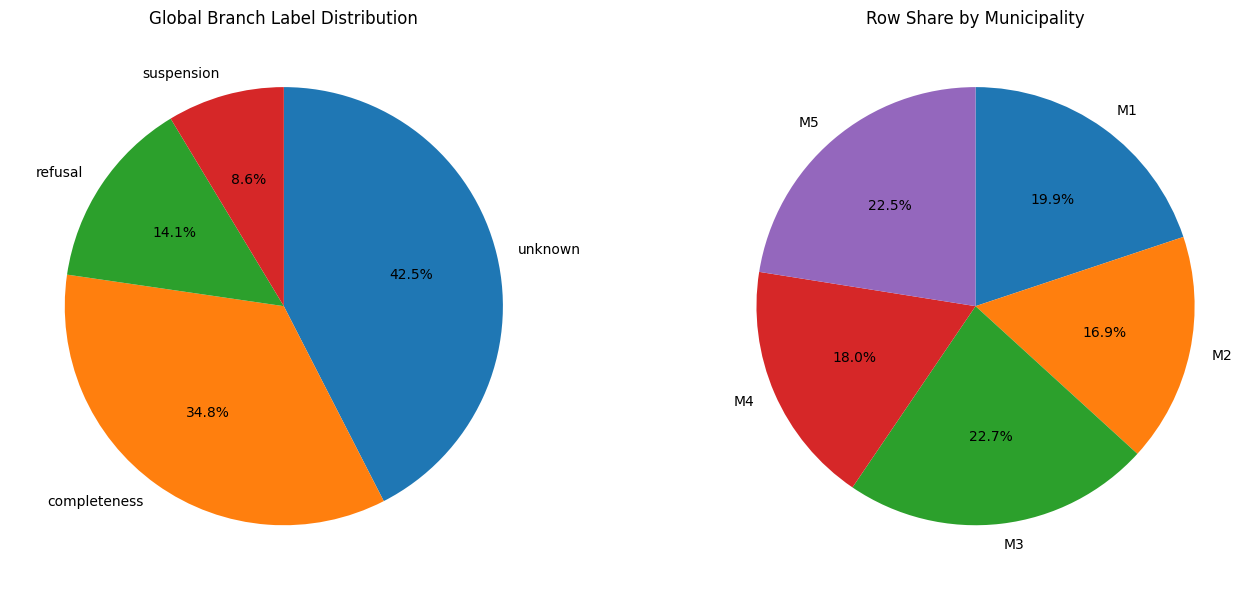

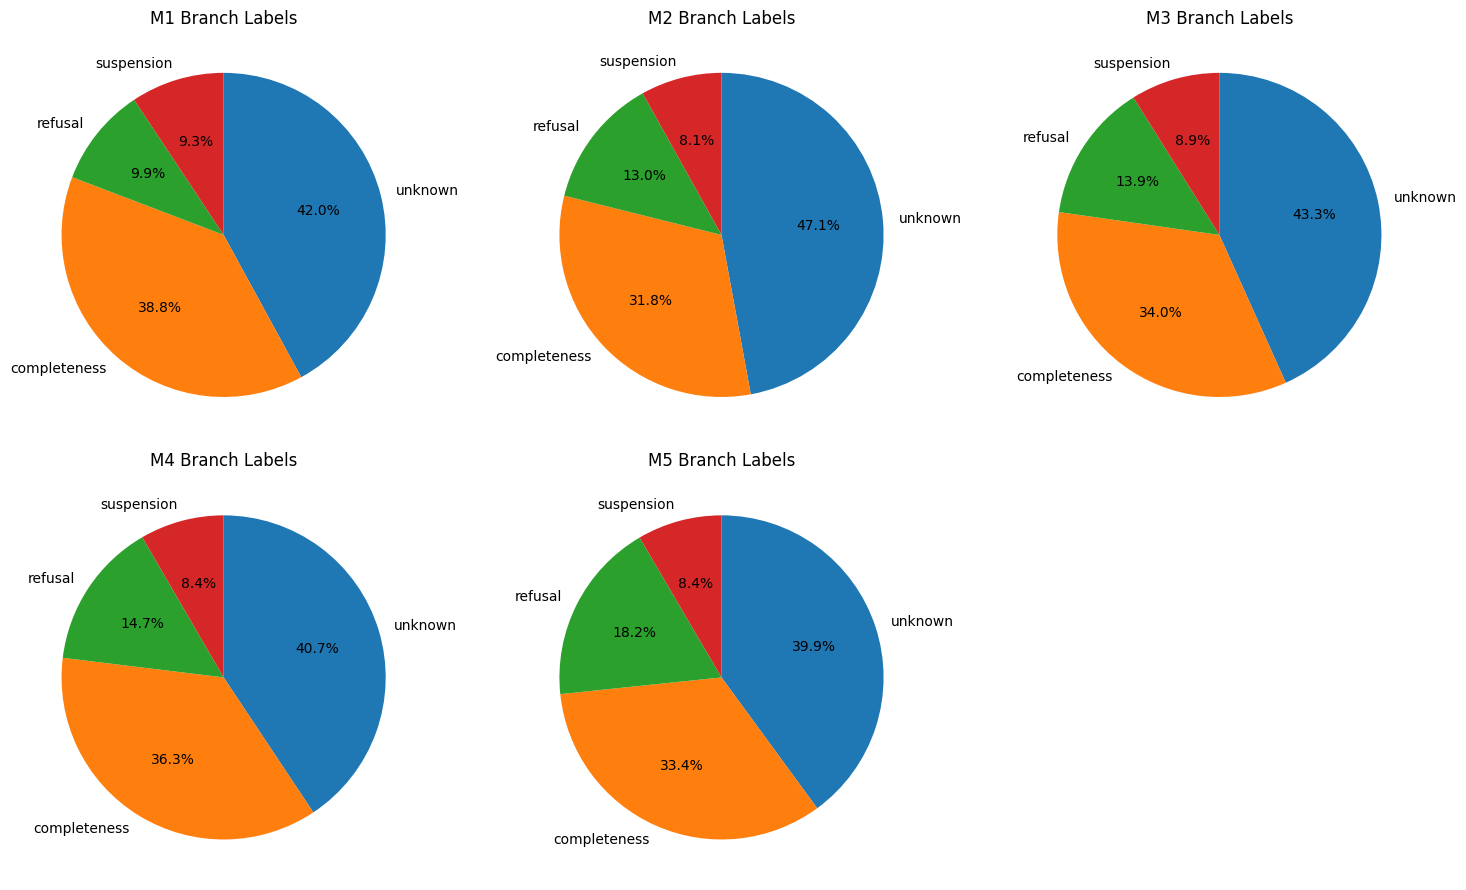

In [ ]:
import math
import matplotlib.pyplot as plt

# Focus columns for quick interpretation
important_feature_cols = [
    'municipality', 'case_id', 'event_id', 'timestamp', 'activity',
    'step_index', 'trace_length', 'stage_rank',
    'time_since_case_start_hours', 'time_since_prev_hours',
    'rework_count_activity', 'seen_activity_before',
    'is_rare_transition_to_next', 'is_backbone_transition_to_next',
    'branch_label', 'branch_confidence',
    'is_terminal_event', 'case_will_complete', 'case_completed'
 ]

# Keep only columns that exist (safe if schema changes slightly)
important_feature_cols = [c for c in important_feature_cols if c in features_df.columns]

# ---------- Row previews ----------
preview_n = 10

print('=== Global important feature rows (first 10) ===')
display(features_df[important_feature_cols].head(preview_n))

print('\n=== Important feature rows by municipality (first 10 each) ===')
for m in sorted(features_df['municipality'].dropna().unique()):
    print(f'\nMunicipality M{int(m)}')
    display(
        features_df.loc[features_df['municipality'] == m, important_feature_cols]
        .head(preview_n)
    )

# ---------- Pie charts: branch-label distribution ----------
label_col = 'branch_label'
branch_global = features_df[label_col].fillna('missing').value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Global pie
axes[0].pie(
    branch_global.values,
    labels=branch_global.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
 )
axes[0].set_title('Global Branch Label Distribution')

# Municipality pie (share of rows by municipality)
m_counts = features_df['municipality'].value_counts().sort_index()
axes[1].pie(
    m_counts.values,
    labels=[f'M{int(m)}' for m in m_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
 )
axes[1].set_title('Row Share by Municipality')

plt.tight_layout()
plt.show()

# Per-municipality branch pies
municipalities = sorted(features_df['municipality'].dropna().unique())
n = len(municipalities)
cols = 3
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
axes = axes.flatten()

for idx, m in enumerate(municipalities):
    ax = axes[idx]
    counts = (
        features_df.loc[features_df['municipality'] == m, label_col]
        .fillna('missing')
        .value_counts()
    )
    ax.pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False
    )
    ax.set_title(f'M{int(m)} Branch Labels')

# Hide any unused subplot axes
for j in range(len(municipalities), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [9]:
# Basic validation checks
dupes = features_df.duplicated(subset=['municipality', 'case_id', 'event_id']).sum()
neg_case = (features_df['time_since_case_start_hours'] < 0).sum()
neg_prev = (features_df['time_since_prev_hours'] < 0).sum()

span_ok = True
for (m, c), g in features_df.groupby(['municipality', 'case_id']):
    expected = list(range(len(g)))
    actual = g.sort_values('step_index')['step_index'].tolist()
    if expected != actual:
        span_ok = False
        break

unknown_rate = float((features_df['branch_label'] == 'unknown').mean())
high_conf_rate = float((features_df['branch_confidence'] >= 0.70).mean())

print('Duplicate (municipality, case_id, event_id):', int(dupes))
print('Negative time_since_case_start_hours:', int(neg_case))
print('Negative time_since_prev_hours:', int(neg_prev))
print('Step index span check passed:', span_ok)
print('Unknown branch rate:', round(unknown_rate, 4))
print('High-confidence branch rate (>=0.70):', round(high_conf_rate, 4))

print('\nBranch source distribution:')
print(features_df['branch_source'].value_counts(dropna=False).to_string())

Duplicate (municipality, case_id, event_id): 0
Negative time_since_case_start_hours: 0
Negative time_since_prev_hours: 0
Step index span check passed: True
Unknown branch rate: 0.4246
High-confidence branch rate (>=0.70): 0.542

Branch source distribution:
branch_source
none                   110438
edge_model              93497
lookahead               57618
lookahead_ambiguous      1075


In [10]:
# Save output (parquet preferred)
parquet_path = OUTPUT_DIR / 'case_step_features.parquet'
csv_path = OUTPUT_DIR / 'case_step_features.csv'

saved_format = None
saved_engine = None
last_parquet_error = None

for engine in ['pyarrow', 'fastparquet']:
    try:
        features_df.to_parquet(parquet_path, engine=engine, index=False)
        saved_format = 'parquet'
        saved_engine = engine
        print(f'Saved parquet using {engine}:', parquet_path.resolve())
        break
    except Exception as e:
        last_parquet_error = e
        print(f'Parquet save failed with {engine}:', str(e))

if saved_format is None:
    features_df.to_csv(csv_path, index=False)
    saved_format = 'csv'
    print('Fell back to CSV:', csv_path.resolve())
    if last_parquet_error is not None:
        print('Last parquet error was:', last_parquet_error)

Saved parquet using pyarrow: /mnt/HDD/Code/Git/bureaucratic-workflow-analyzer/output/case_step_features.parquet


## Step 2 complete

You now have a case-step feature table ready for Step 3 (duration and branch statistics for simulator calibration).